In [166]:
!pip install scikit-learn

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [167]:
'''
Import Libraries
Create or Load Dataset
Data Cleaning, EDA and Feature Engineering
Divide into input and output columns
Train-test split
Train the model
Model Parameters
Prediction
Model Evaluation
Regression Line
Predict New Values
'''

'\nImport Libraries\nCreate or Load Dataset\nData Cleaning, EDA and Feature Engineering\nDivide into input and output columns\nTrain-test split\nTrain the model\nModel Parameters\nPrediction\nModel Evaluation\nRegression Line\nPredict New Values\n'

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [169]:
data = {
    'Height' : [145, 148, 150, 152, 155, 157, 160, 162, 165, 167, 170, 172, 175, 177, 180, 182, 185, 187, 190, 192],
    'Weight' : [42, 44, 46, 48, 50, 53, 55, 57, 60, 62, 65, 67, 70, 72, 75, 78, 82, 85, 89, 92]
}
data

{'Height': [145,
  148,
  150,
  152,
  155,
  157,
  160,
  162,
  165,
  167,
  170,
  172,
  175,
  177,
  180,
  182,
  185,
  187,
  190,
  192],
 'Weight': [42,
  44,
  46,
  48,
  50,
  53,
  55,
  57,
  60,
  62,
  65,
  67,
  70,
  72,
  75,
  78,
  82,
  85,
  89,
  92]}

In [170]:
df = pd.DataFrame(data)

In [171]:
df.head()

,Height,Weight
0,145,42
1,148,44
2,150,46
3,152,48
4,155,50


In [172]:
df.shape

(20, 2)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Height  20 non-null     int64
 1   Weight  20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes


In [174]:
df.describe()

,Height,Weight
count,20.000000,20.000000
mean,168.550000,64.600000
std,14.695058,15.432024
min,145.000000,42.000000
25%,156.500000,52.250000
50%,168.500000,63.500000
75%,180.500000,75.750000
max,192.000000,92.000000


In [175]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

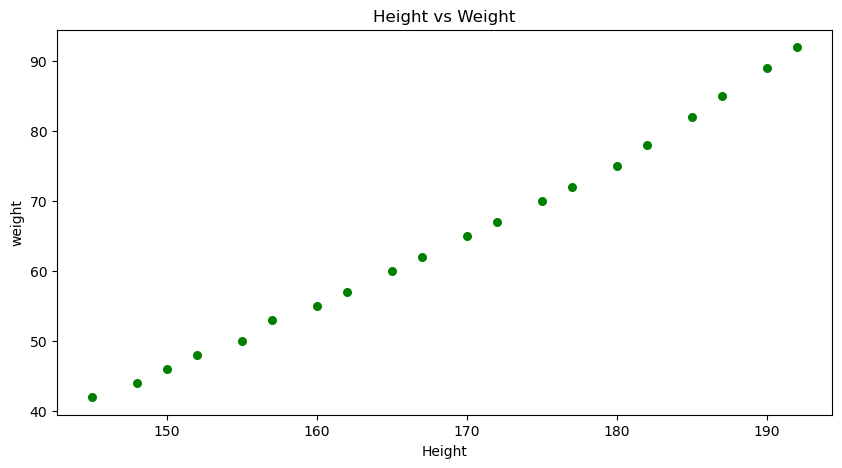

In [176]:
plt.figure(figsize=(10,5))
plt.scatter(df['Height'], df['Weight'], color = 'green', s=30)
plt.xlabel('Height')
plt.ylabel('weight')
plt.title('Height vs Weight')
plt.show()

In [177]:
df.corr()

,Height,Weight
Height,1.000000,0.996445
Weight,0.996445,1.000000


In [178]:
df

,Height,Weight
0,145,42
1,148,44
2,150,46
3,152,48
4,155,50
5,157,53
6,160,55
7,162,57
8,165,60
9,167,62


In [179]:
x = df[['Height']]
y = df[['Weight']]

In [180]:
x

,Height
0,145
1,148
2,150
3,152
4,155
5,157
6,160
7,162
8,165
9,167


In [181]:
y

,Weight
0,42
1,44
2,46
3,48
4,50
5,53
6,55
7,57
8,60
9,62


In [182]:

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1)


In [183]:
model = LinearRegression()

In [184]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [185]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [186]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [187]:
# Weight = m * Height + c  --> y = mx + c

In [188]:
print('Slope (Coefficient):', model.coef_[0])
print('Intercept:', model.intercept_)

Slope (Coefficient): [1.04770115]
Intercept: [-111.93649425]


In [189]:
type(model.coef_)

numpy.ndarray

In [194]:
y_pred = model.predict(x_test)

results = pd.DataFrame({
    'Actual Weight': y_test.values.flatten(),
    'Predict Weight': y_pred.flatten()
})

In [192]:
results

,Actual Weight,Predict Weight
0,48,47.314080
1,82,81.888218
2,55,55.695690
3,65,66.172701


In [196]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):",r2)

Mean Absolute Error (MAE): 0.6665229885057471
Mean Squared Error (MSE): 0.5855482065001916
Root Mean Squared Error (RMSE): 0.7652112169200028
R-squared (R2): 0.9964131809709024


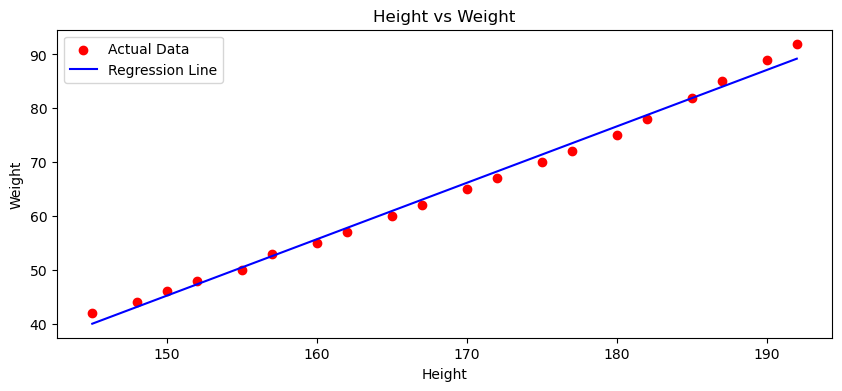

In [199]:
plt.figure(figsize=(10,4))
plt.scatter(x,y, color='red',label='Actual Data')
plt.plot(x, model.predict(x), color='blue', label = 'Regression Line')
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

In [200]:
import warnings
warnings.filterwarnings('ignore')

In [202]:
new_height = np.array([[178]])
predicted_weight =  model.predict(new_height)
print("predicted_weight:", predicted_weight[0])

predicted_weight: [74.55431034]


In [205]:
heights = pd.DataFrame({
    'Height' : [150, 160, 170, 180, 190]
})

predictions = model.predict(heights)

result = heights.copy()
result['Predicted Weight'] = predictions

result

,Height,Predicted Weight
0,150,45.218678
1,160,55.695690
2,170,66.172701
3,180,76.649713
4,190,87.126724
